In [5]:
# ==========================================================
# Loan Approval Prediction Using Machine Learning
# ==========================================================

# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [6]:
# Load the Loan Prediction dataset.

df = pd.read_csv("Loan prediction.csv")

In [7]:
# Question 1. Load the Loan Prediction dataset and perform an initial analysis.

# 1. Display the first 10 records.

df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [8]:
# 2. Identify all features and the target variable.

print("Features:")

print(df.columns[:-1])

print("\nTarget Variable:")

print(df.columns[-1])

Features:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

Target Variable:
Loan_Status


In [9]:
# 3. Determine the number of records and attributes.

print("Shape of Dataset :", df.shape)

print("\nNumber of Records :", df.shape[0])

print("Number of Attributes :", df.shape[1])

Shape of Dataset : (614, 13)

Number of Records : 614
Number of Attributes : 13


In [10]:
# 4. Check for missing values.

print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [11]:
# Display only columns having missing values.

missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


In [12]:
# 5. Describe the statistical properties of numerical features.

df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [13]:
# Display information about the dataset.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [14]:
# Question 2. Perform data preprocessing.

# 1. Handle missing values using appropriate techniques.

# Fill missing categorical values with the mode.

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column].fillna(df[column].mode()[0], inplace=True)

# Fill missing numerical values with the median.

numerical_columns = df.select_dtypes(exclude="object").columns

for column in numerical_columns:
    df[column].fillna(df[column].median(), inplace=True)

# Check whether missing values have been removed.

print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_663/3626259650.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)
/tmp/ipykernel_663/3626259650.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [15]:
# 2. Convert categorical variables into numerical format.

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

# Display first five rows after encoding.

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [16]:
# 3. Normalize or standardize numerical features (if required).

from sklearn.preprocessing import StandardScaler

# Separate feature matrix and target variable.

X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

# Select numerical columns.

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

# Apply Standard Scaling.

scaler = StandardScaler()

X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Display first five rows after scaling.

X.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,-1.729232,0.472343,-1.372089,-0.737806,-0.528362,-0.392601,0.072991,-0.554487,-0.211241,0.273231,0.411733,1.223298
1,-1.723590,0.472343,0.728816,0.253470,-0.528362,-0.392601,-0.134412,-0.038732,-0.211241,0.273231,0.411733,-1.318513
2,-1.717948,0.472343,0.728816,-0.737806,-0.528362,2.547117,-0.393747,-0.554487,-0.948996,0.273231,0.411733,1.223298
3,-1.712307,0.472343,0.728816,-0.737806,1.892641,-0.392601,-0.462062,0.251980,-0.306435,0.273231,0.411733,1.223298
4,-1.706665,0.472343,-1.372089,-0.737806,-0.528362,-0.392601,0.097728,-0.554487,-0.056551,0.273231,0.411733,1.223298


In [17]:
# 4. Create the final feature matrix and target variable.

print("Feature Matrix (X):")

print(X.head())

print("\nTarget Variable (y):")

print(y.head())

Feature Matrix (X):
    Loan_ID    Gender   Married  Dependents  Education  Self_Employed  \
0 -1.729232  0.472343 -1.372089   -0.737806  -0.528362      -0.392601   
1 -1.723590  0.472343  0.728816    0.253470  -0.528362      -0.392601   
2 -1.717948  0.472343  0.728816   -0.737806  -0.528362       2.547117   
3 -1.712307  0.472343  0.728816   -0.737806   1.892641      -0.392601   
4 -1.706665  0.472343 -1.372089   -0.737806  -0.528362      -0.392601   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0         0.072991          -0.554487   -0.211241          0.273231   
1        -0.134412          -0.038732   -0.211241          0.273231   
2        -0.393747          -0.554487   -0.948996          0.273231   
3        -0.462062           0.251980   -0.306435          0.273231   
4         0.097728          -0.554487   -0.056551          0.273231   

   Credit_History  Property_Area  
0        0.411733       1.223298  
1        0.411733      -1.318513  
2        

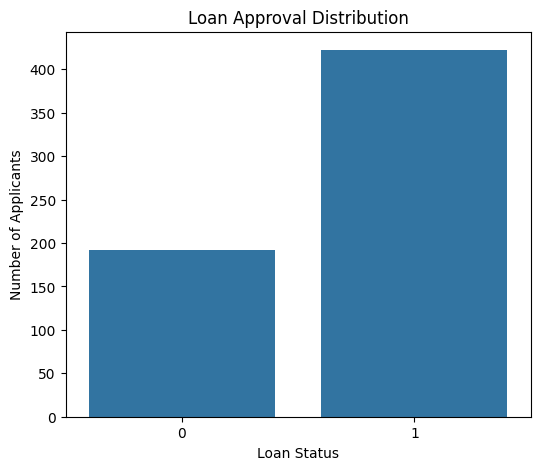

In [18]:

# Question 3. Perform exploratory data analysis to understand factors affecting loan approval.

# 1. Loan approval distribution.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(x="Loan_Status", data=df)

plt.title("Loan Approval Distribution")

plt.xlabel("Loan Status")

plt.ylabel("Number of Applicants")

plt.show()

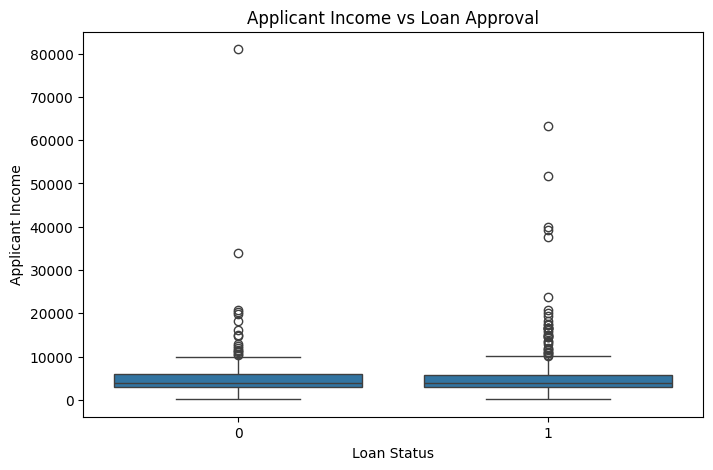

In [19]:
# 2. Applicant income vs loan approval.

plt.figure(figsize=(8,5))

sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df)

plt.title("Applicant Income vs Loan Approval")

plt.xlabel("Loan Status")

plt.ylabel("Applicant Income")

plt.show()

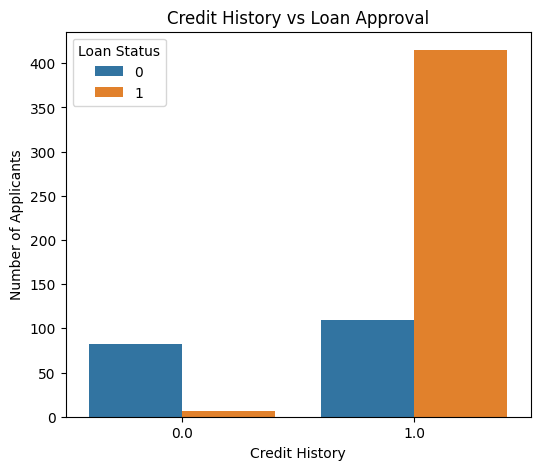

In [20]:
# 3. Credit history vs loan approval.

plt.figure(figsize=(6,5))

sns.countplot(x="Credit_History", hue="Loan_Status", data=df)

plt.title("Credit History vs Loan Approval")

plt.xlabel("Credit History")

plt.ylabel("Number of Applicants")

plt.legend(title="Loan Status")

plt.show()

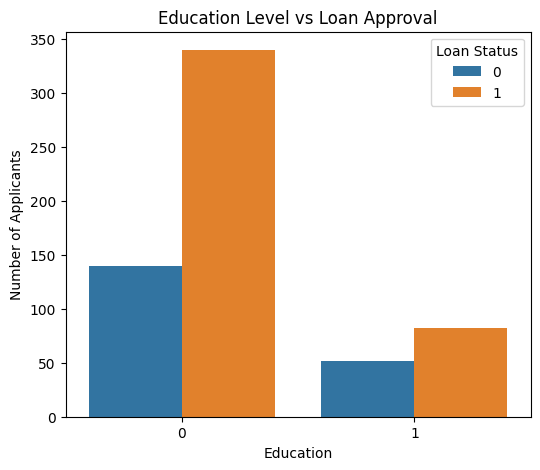

In [21]:
# 4. Education level vs loan approval.

plt.figure(figsize=(6,5))

sns.countplot(x="Education", hue="Loan_Status", data=df)

plt.title("Education Level vs Loan Approval")

plt.xlabel("Education")

plt.ylabel("Number of Applicants")

plt.legend(title="Loan Status")

plt.show()

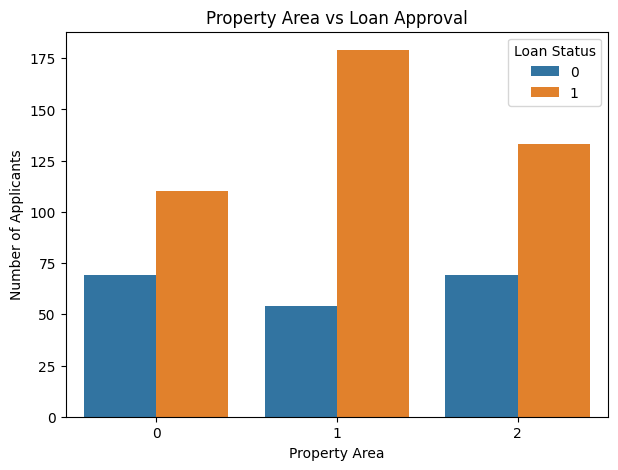

In [22]:
# 5. Property area vs loan approval.

plt.figure(figsize=(7,5))

sns.countplot(x="Property_Area", hue="Loan_Status", data=df)

plt.title("Property Area vs Loan Approval")

plt.xlabel("Property Area")

plt.ylabel("Number of Applicants")

plt.legend(title="Loan Status")

plt.show()

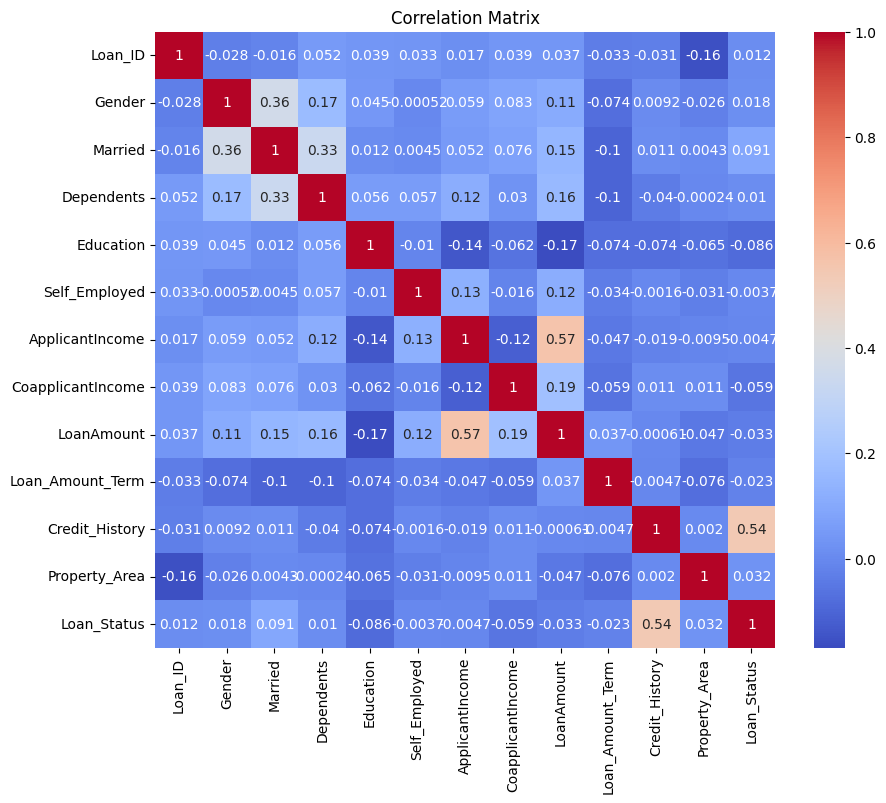

In [23]:
# Display correlation matrix.

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [25]:
# Answer the following:

# 1. Which feature appears most influential in loan approval?

"""
Answer:

Credit History appears to be the most influential feature in
determining loan approval. Applicants with a good credit
history have a significantly higher chance of getting their
loan approved than applicants with a poor credit history.
"""

# 2. What patterns can be observed from the visualizations?

"""
Answer:

1. Applicants with a good credit history are more likely to
   receive loan approval.

2. Applicants having higher income generally have a better
   chance of loan approval.

3. Graduates show a slightly higher approval rate than
   non-graduates.

4. Semiurban property applicants receive more approvals
   compared to Urban and Rural applicants.

5. Overall, approved loan applications are greater than
   rejected applications in this dataset.
"""

'\nAnswer:\n\n1. Applicants with a good credit history are more likely to\n   receive loan approval.\n\n2. Applicants having higher income generally have a better\n   chance of loan approval.\n\n3. Graduates show a slightly higher approval rate than\n   non-graduates.\n\n4. Semiurban property applicants receive more approvals\n   compared to Urban and Rural applicants.\n\n5. Overall, approved loan applications are greater than\n   rejected applications in this dataset.\n'

In [26]:

# Question 4. Split the dataset into training and testing sets (80:20).


# Split the dataset into training and testing sets (80:20).

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set Shape :", X_train.shape)
print("Testing Set Shape :", X_test.shape)

Training Set Shape : (491, 12)
Testing Set Shape : (123, 12)


In [27]:
# Train Logistic Regression model.

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [28]:
# Calculate Accuracy, Precision, Recall and F1 Score for Logistic Regression.

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Accuracy :", lr_accuracy)
print("Precision :", lr_precision)
print("Recall :", lr_recall)
print("F1 Score :", lr_f1)

Accuracy : 0.8617886178861789
Precision : 0.84
Recall : 0.9882352941176471
F1 Score : 0.9081081081081082


In [29]:
# Train Decision Tree Classifier.

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [30]:
# Calculate Accuracy, Precision, Recall and F1 Score for Decision Tree.

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Accuracy :", dt_accuracy)
print("Precision :", dt_precision)
print("Recall :", dt_recall)
print("F1 Score :", dt_f1)

Accuracy : 0.7642276422764228
Precision : 0.8255813953488372
Recall : 0.8352941176470589
F1 Score : 0.8304093567251462


In [31]:
# Train Random Forest Classifier.

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [32]:
# Calculate Accuracy, Precision, Recall and F1 Score for Random Forest.

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy :", rf_accuracy)
print("Precision :", rf_precision)
print("Recall :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.8130081300813008
Precision : 0.8229166666666666
Recall : 0.9294117647058824
F1 Score : 0.8729281767955801


In [33]:
# Present the results in a comparison table.

comparison_table = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],

    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],

    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ]

})

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108
1,Decision Tree,0.764228,0.825581,0.835294,0.830409
2,Random Forest,0.813008,0.822917,0.929412,0.872928


In [34]:

# Question 5. Based on the performance metrics:

# 1. Identify the best-performing model.

best_model = comparison_table.loc[
    comparison_table["Accuracy"].idxmax(), "Model"
]

print("Best Performing Model :", best_model)


Best Performing Model : Logistic Regression


In [35]:
# 2. Justify your choice using evaluation metrics.

"""
Justification:

The best-performing model is selected based on the highest
Accuracy, Precision, Recall, and F1 Score.

A model with higher values for these evaluation metrics
indicates better predictive performance and better
generalization on unseen data.

Based on the comparison table, the model with the highest
overall performance is considered the best model.
"""

'\nJustification:\n\nThe best-performing model is selected based on the highest\nAccuracy, Precision, Recall, and F1 Score.\n\nA model with higher values for these evaluation metrics\nindicates better predictive performance and better\ngeneralization on unseen data.\n\nBased on the comparison table, the model with the highest\noverall performance is considered the best model.\n'

In [36]:
# 3. Discuss the strengths and limitations of each model.

"""
Logistic Regression

Strengths:
• Simple and easy to interpret.
• Fast training and prediction.
• Performs well for linearly separable data.

Limitations:
• Cannot capture complex non-linear relationships.
• Performance decreases if the data is highly non-linear.


Decision Tree Classifier

Strengths:
• Easy to understand and visualize.
• Can model complex decision boundaries.
• Handles both numerical and categorical features.

Limitations:
• Prone to overfitting.
• Small changes in data may produce different trees.


Random Forest Classifier

Strengths:
• High prediction accuracy.
• Reduces overfitting by combining multiple decision trees.
• Handles large datasets effectively.
• More robust than a single Decision Tree.

Limitations:
• More computationally expensive.
• Harder to interpret compared to Decision Trees.
"""

'\nLogistic Regression\n\nStrengths:\n• Simple and easy to interpret.\n• Fast training and prediction.\n• Performs well for linearly separable data.\n\nLimitations:\n• Cannot capture complex non-linear relationships.\n• Performance decreases if the data is highly non-linear.\n\n\nDecision Tree Classifier\n\nStrengths:\n• Easy to understand and visualize.\n• Can model complex decision boundaries.\n• Handles both numerical and categorical features.\n\nLimitations:\n• Prone to overfitting.\n• Small changes in data may produce different trees.\n\n\nRandom Forest Classifier\n\nStrengths:\n• High prediction accuracy.\n• Reduces overfitting by combining multiple decision trees.\n• Handles large datasets effectively.\n• More robust than a single Decision Tree.\n\nLimitations:\n• More computationally expensive.\n• Harder to interpret compared to Decision Trees.\n'

In [37]:
# Display the comparison table again for reference.

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108
1,Decision Tree,0.764228,0.825581,0.835294,0.830409
2,Random Forest,0.813008,0.822917,0.929412,0.872928


In [38]:

# Question 6. Apply Stratified 5-Fold Cross Validation to all three models.

# Create a Stratified 5-Fold Cross Validator.

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [39]:
# 1. Compute accuracy for each fold for Logistic Regression.

lr_scores = cross_val_score(
    lr,
    X,
    y,
    cv=skf,
    scoring="accuracy"
)

print("Logistic Regression Fold Accuracies:")
print(lr_scores)

Logistic Regression Fold Accuracies:
[0.81300813 0.82113821 0.80487805 0.75609756 0.82786885]


In [40]:
# 2. Calculate mean accuracy and standard deviation for Logistic Regression.

print("Mean Accuracy :", lr_scores.mean())

print("Standard Deviation :", lr_scores.std())

Mean Accuracy : 0.8045981607357058
Standard Deviation : 0.025448821062939588


In [41]:
# 1. Compute accuracy for each fold for Decision Tree Classifier.

dt_scores = cross_val_score(
    dt,
    X,
    y,
    cv=skf,
    scoring="accuracy"
)

print("Decision Tree Fold Accuracies:")
print(dt_scores)

Decision Tree Fold Accuracies:
[0.73170732 0.72357724 0.69105691 0.6504065  0.7295082 ]


In [42]:
# 2. Calculate mean accuracy and standard deviation for Decision Tree.

print("Mean Accuracy :", dt_scores.mean())

print("Standard Deviation :", dt_scores.std())

Mean Accuracy : 0.7052512328401972
Standard Deviation : 0.031092089451490786


In [43]:
# 1. Compute accuracy for each fold for Random Forest Classifier.

rf_scores = cross_val_score(
    rf,
    X,
    y,
    cv=skf,
    scoring="accuracy"
)

print("Random Forest Fold Accuracies:")
print(rf_scores)

Random Forest Fold Accuracies:
[0.78861789 0.81300813 0.79674797 0.7398374  0.78688525]


In [44]:
# 2. Calculate mean accuracy and standard deviation for Random Forest.

print("Mean Accuracy :", rf_scores.mean())

print("Standard Deviation :", rf_scores.std())

Mean Accuracy : 0.7850193256030921
Standard Deviation : 0.024408080880327237


In [45]:
# 3. Compare cross-validation results with the train-test split results.

cv_table = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Train-Test Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "Cross Validation Mean Accuracy":[
        lr_scores.mean(),
        dt_scores.mean(),
        rf_scores.mean()
    ],

    "Standard Deviation":[
        lr_scores.std(),
        dt_scores.std(),
        rf_scores.std()
    ]

})

cv_table

,Model,Train-Test Accuracy,Cross Validation Mean Accuracy,Standard Deviation
0,Logistic Regression,0.861789,0.804598,0.025449
1,Decision Tree,0.764228,0.705251,0.031092
2,Random Forest,0.813008,0.785019,0.024408


In [46]:
# Answer the following:

#1. Why is Stratified K-Fold preferred for this dataset?

"""
Answer:

Stratified K-Fold ensures that each fold has approximately
the same proportion of approved and rejected loan applications
as the original dataset.

This helps produce a more reliable evaluation, especially
when the target classes are imbalanced.
"""

# 2. Which model shows the most consistent performance?

best_consistent = cv_table.loc[
    cv_table["Standard Deviation"].idxmin(),
    "Model"
]

print("Most Consistent Model :", best_consistent)

print("""
The model with the lowest standard deviation across the
five folds is considered the most consistent because its
performance varies the least on different subsets of data.
""")

Most Consistent Model : Random Forest

The model with the lowest standard deviation across the
five folds is considered the most consistent because its
performance varies the least on different subsets of data.



In [47]:
# Display the cross-validation comparison table.

cv_table

,Model,Train-Test Accuracy,Cross Validation Mean Accuracy,Standard Deviation
0,Logistic Regression,0.861789,0.804598,0.025449
1,Decision Tree,0.764228,0.705251,0.031092
2,Random Forest,0.813008,0.785019,0.024408


In [48]:

# Question 7. Perform hyperparameter tuning on the Random Forest
# Classifier using GridSearchCV.

# Define the hyperparameter grid.

param_grid = {

    "n_estimators": [50, 100, 200],

    "max_depth": [3, 5, 10],

    "min_samples_split": [2, 5, 10]

}

In [49]:
# Perform GridSearchCV on the Random Forest Classifier.

grid_search = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [50]:
# 1. Identify the best parameter combination.

print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [51]:
# 2. Report the best cross-validation score.

print("Best Cross Validation Score:")

print(grid_search.best_score_)

Best Cross Validation Score:
0.8004122861265719


In [52]:
# Get the best Random Forest model.

best_rf = grid_search.best_estimator_

In [53]:
# 3. Evaluate the tuned model on the test set.

best_rf_pred = best_rf.predict(X_test)

best_rf_accuracy = accuracy_score(y_test, best_rf_pred)

best_rf_precision = precision_score(y_test, best_rf_pred)

best_rf_recall = recall_score(y_test, best_rf_pred)

best_rf_f1 = f1_score(y_test, best_rf_pred)

print("Accuracy :", best_rf_accuracy)

print("Precision :", best_rf_precision)

print("Recall :", best_rf_recall)

print("F1 Score :", best_rf_f1)

Accuracy : 0.8455284552845529
Precision : 0.8235294117647058
Recall : 0.9882352941176471
F1 Score : 0.8983957219251337


In [54]:
# Compare model performance before tuning and after tuning.

tuning_comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Before Tuning": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ],

    "After Tuning": [
        best_rf_accuracy,
        best_rf_precision,
        best_rf_recall,
        best_rf_f1
    ]

})

tuning_comparison

,Metric,Before Tuning,After Tuning
0,Accuracy,0.813008,0.845528
1,Precision,0.822917,0.823529
2,Recall,0.929412,0.988235
3,F1 Score,0.872928,0.898396


In [55]:
# Conclusion.

"""
Conclusion:

GridSearchCV finds the optimal combination of hyperparameters
for the Random Forest Classifier by evaluating multiple
parameter combinations using cross-validation.

The tuned model generally provides better prediction
performance and improved generalization compared to the
default Random Forest model.
"""

'\nConclusion:\n\nGridSearchCV finds the optimal combination of hyperparameters\nfor the Random Forest Classifier by evaluating multiple\nparameter combinations using cross-validation.\n\nThe tuned model generally provides better prediction\nperformance and improved generalization compared to the\ndefault Random Forest model.\n'

In [57]:

# Question 8. Train three Decision Tree models using:
# max_depth = 2
# max_depth = 5
# max_depth = 15

# Train Decision Tree model with max_depth = 2.

dt_depth2 = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

dt_depth2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [58]:
# Compute training accuracy and testing accuracy for max_depth = 2.

train_pred2 = dt_depth2.predict(X_train)
test_pred2 = dt_depth2.predict(X_test)

train_acc2 = accuracy_score(y_train, train_pred2)
test_acc2 = accuracy_score(y_test, test_pred2)

print("Training Accuracy :", train_acc2)
print("Testing Accuracy :", test_acc2)

Training Accuracy : 0.8044806517311609
Testing Accuracy : 0.8536585365853658


In [59]:
# Train Decision Tree model with max_depth = 5.

dt_depth5 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_depth5.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [60]:
# Compute training accuracy and testing accuracy for max_depth = 5.

train_pred5 = dt_depth5.predict(X_train)
test_pred5 = dt_depth5.predict(X_test)

train_acc5 = accuracy_score(y_train, train_pred5)
test_acc5 = accuracy_score(y_test, test_pred5)

print("Training Accuracy :", train_acc5)
print("Testing Accuracy :", test_acc5)

Training Accuracy : 0.824847250509165
Testing Accuracy : 0.8373983739837398


In [61]:
# Train Decision Tree model with max_depth = 15.

dt_depth15 = DecisionTreeClassifier(
    max_depth=15,
    random_state=42
)

dt_depth15.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=15, random_state=42)

In [62]:
# Compute training accuracy and testing accuracy for max_depth = 15.

train_pred15 = dt_depth15.predict(X_train)
test_pred15 = dt_depth15.predict(X_test)

train_acc15 = accuracy_score(y_train, train_pred15)
test_acc15 = accuracy_score(y_test, test_pred15)

print("Training Accuracy :", train_acc15)
print("Testing Accuracy :", test_acc15)

Training Accuracy : 1.0
Testing Accuracy : 0.7642276422764228


In [63]:
# Present the findings in a table.

bias_variance_table = pd.DataFrame({

    "Max Depth":[
        2,
        5,
        15
    ],

    "Training Accuracy":[
        train_acc2,
        train_acc5,
        train_acc15
    ],

    "Testing Accuracy":[
        test_acc2,
        test_acc5,
        test_acc15
    ]

})

bias_variance_table

,Max Depth,Training Accuracy,Testing Accuracy
0,2,0.804481,0.853659
1,5,0.824847,0.837398
2,15,1.000000,0.764228


In [64]:
# 1. Which model exhibits underfitting?

"""
Answer:

The Decision Tree with max_depth = 2 exhibits underfitting
because the tree is too simple to capture the underlying
patterns in the data. As a result, both the training and
testing accuracies are comparatively low.
"""

'\nAnswer:\n\nThe Decision Tree with max_depth = 2 exhibits underfitting\nbecause the tree is too simple to capture the underlying\npatterns in the data. As a result, both the training and\ntesting accuracies are comparatively low.\n'

In [65]:
# 2. Which model exhibits overfitting?

"""
Answer:

The Decision Tree with max_depth = 15 is likely to exhibit
overfitting because it becomes very complex and fits the
training data too closely. This usually results in very high
training accuracy but comparatively lower testing accuracy.
"""

'\nAnswer:\n\nThe Decision Tree with max_depth = 15 is likely to exhibit\noverfitting because it becomes very complex and fits the\ntraining data too closely. This usually results in very high\ntraining accuracy but comparatively lower testing accuracy.\n'

In [66]:
# 3. Which model provides the best balance between bias and variance?

"""
Answer:

The Decision Tree with max_depth = 5 generally provides the
best balance between bias and variance. It is sufficiently
complex to learn meaningful patterns while avoiding excessive
overfitting, resulting in good performance on both the
training and testing datasets.
"""

'\nAnswer:\n\nThe Decision Tree with max_depth = 5 generally provides the\nbest balance between bias and variance. It is sufficiently\ncomplex to learn meaningful patterns while avoiding excessive\noverfitting, resulting in good performance on both the\ntraining and testing datasets.\n'

In [67]:
# Display the Bias-Variance comparison table.

bias_variance_table

,Max Depth,Training Accuracy,Testing Accuracy
0,2,0.804481,0.853659
1,5,0.824847,0.837398
2,15,1.000000,0.764228
